# 🏛️ Trabajo Práctico de Álgebra Lineal Computacional (ALC) 🏛️

## 🗓️ 2do Cuatrimestre - Año 2025 🗓️

---

### 🚀 Nombre del grupo: Grupo Turno Mañana 🚀
(Super original el nombre)

---

### 🧑‍💻 Integrantes 🧑‍💻

* **Manuel Romero** - Legajo: `665/23`
* **Felipe Martin** - Legajo: `542/22`
* **Francisco Lingua** - Legajo: `68/22`
* **Santiago Wingeyer** - Legajo: `362/22` 

---

_¡Juntos construyendo el futuro del Álgebra Lineal!_ (Google Gemini estuvo por aquí)

# 💡 ACLARACIONES 


Hemos implementado todas las funciones requeridas en los laboratorios. Sin embargo, para que el tiempo de ejecución del TP sea razonable, tuvimos que realizar optimizaciones en algunas de ellas.

⚡️ Optimización y Vectorización

Las optimizaciones implementadas se basan en la vectorización y la delegación de operaciones pesadas a librerías:

* Utilizamos el operador @ de NumPy en lugar de nuestra función manual multi_matricial.

* Utilizamos la función eigh importada (from scipy.linalg import eigh). Esta es la implementación de SciPy que calcula los autovalores y autovectores de una matriz hermitiana (simétrica), reemplazando nuestra funcion diagRH. Si bien intentamos optimizar nuestra implementación manual de diagRH, no logramos que corriera en un tiempo razonable  (siempre tardaba un googol de años).

📁 Estructura del Archivo alc.py
Dentro de la carpeta TP-ALC, encontrarán el archivo alc.py con todas las funciones implementadas. A continuación, un índice para facilitar la navegación:

* Si buscan '##': Encontraran el principio de una nueva seccion que puede ser:

* 'Laboratorio i' (reemplazando i por el número de labo): Contiene la implementación original de todas las funciones obligatorias de dicho laboratorio. Esta es la versión original que sigue los pseudo-códigos subidos al campus.

* 'Funciones necesarias para el Trabajo Practico': Contiene las funciones auxiliares implementadas para resolver las consignas del TP.

* Ejercicio i' (reemplazando i por el número de ej): Contiene las implementaciones de los ejercicios solicitados en la consigna del TP.

* 'Funciones optimizadas para poder correr el TP en un tiempo razonable': Contiene las optimizaciones que tuvimos que realizar. En su interior encontrarán comentarios sobre las partes modificadas para comparar la lógica original con la optimización (cálculos vectorizados, uso de @ o eigh).

# Imports para los ejercicios

In [1]:
from alc import *

# Cargamos el dataset




In [2]:
carpetaGatosYPerros = 'template-alumnos/dataset/cats_and_dogs'
Xt, Yt, Xv, Yv = cargarDataset(carpetaGatosYPerros)

En la siguiente seccion generamos las matrices de pesos mediante los metodos requeridos por la catedra. Las funciones pinv generan las matrices de pesos calculando la pseudoinversa de la matriz de embeddings, por lo que hacemos un chequeo en cada funcion que determina si la matriz obtenida para calcular la matriz de pesos es o no la pseudoinversa. Notar que la matriz que se devuelve no es la pseudoinversa. 

# Generamos la matriz de pesos con Ecuaciones Normales

In [3]:

# En el contexto del TP n < p, entonces para el algoritmo 1 aplicamos Cholesky sobre X @ X^T
print('Inició WEN')
tiempo_inicio_EN = time.perf_counter()
## CORRECCION: cambio de nombre de cholesky a calculaCholesky
L = calculaCholesky(multi_matricial(Xt, traspuesta(Xt)))
## CORRECCION: pinvEcuacionesNormales ahora solo devuelve W
WEN = pinvEcuacionesNormales(Xt, L , Yt)
tiempo_fin_EN = time.perf_counter()
print('Terminó WEN')
matriz_de_confusion_EN = generarMatrizDeConfusion(WEN, Xv, Yv)

Inició WEN
Es pseudo-inversa con EN:  False
Terminó WEN


# Generamos la matriz de pesos con SVD

In [4]:

print('Inició WSVD')
tiempo_inicio_SVD = time.perf_counter()
U, s_vector, V = svd_reducida_optimizado(Xt)
S = np.diag(s_vector)
## CORRECCION: pinvSVD ahora solo devuelve W
WSVD = pinvSVD(U, S, V, Yt)
tiempo_fin_SVD = time.perf_counter()
print('Terminó WSVD')
matriz_de_confusion_SVD = generarMatrizDeConfusion(WSVD, Xv, Yv)


Inició WSVD
Es pseudo-inversa con SVD:  False
Terminó WSVD


# Generamos la matriz de pesos con QR con Householder

In [5]:
print('Inició WQRHH')
tiempo_inicio_QRHH = time.perf_counter()
QHH, RHH = QR_con_HH_optimizado(traspuesta(Xt))
## CORRECCION: pinvHouseHolder ahora solo devuelve W
WQRHH = pinvHouseHolder(QHH, RHH, Yt)
tiempo_fin_QRHH = time.perf_counter()
print('Terminó WQRHH')
matriz_de_confusion_WQRHH = generarMatrizDeConfusion(WQRHH, Xv, Yv)


Inició WQRHH
Es pseudo-inversa con QRHH:  False
Terminó WQRHH


# Generamos la matriz de pesos con QR con Gram Schmidt

In [6]:
print('Inició WQRGS')
tiempo_inicio_QRGS = time.perf_counter()
QGS, RGS = QR_con_GS(traspuesta(Xt))
## CORRECCION: pinvGramSchmidt ahora solo devuelve W
WQRGS = pinvGramSchmidt(QGS, RGS, Yt)
tiempo_fin_QRGS = time.perf_counter()
print('Terminó WQRGS')
matriz_de_confusion_WQRGS = generarMatrizDeConfusion(WQRGS, Xv, Yv)


Inició WQRGS
Es pseudo-inversa con QRGS:  False
Terminó WQRGS


# Generacion de graficos de comparacion


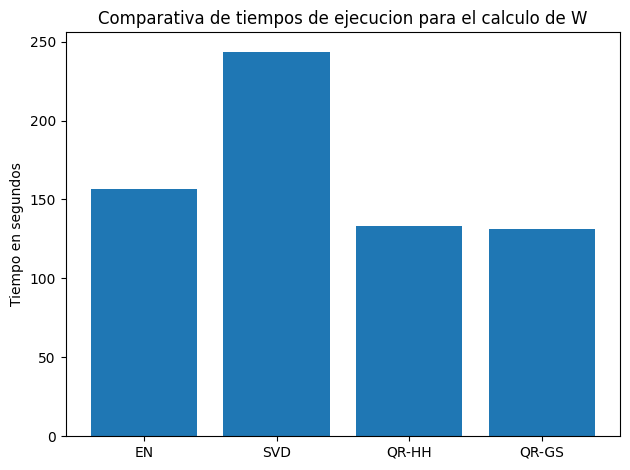

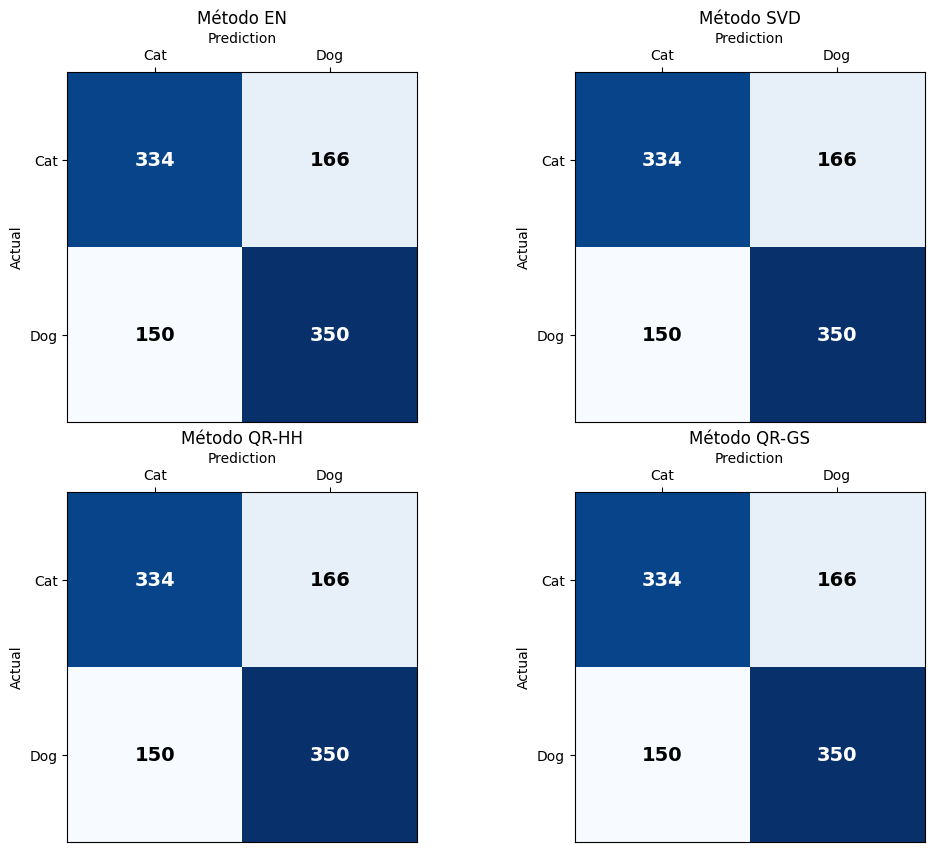

In [ ]:
# Aclaración: antes las funciones pinv devolvían la pseudoinversa para poder saber medir el tiempo de ejecución de las funciones que calculan las W. 
# Ahora se está contando el tiempo en que se tarda calcualr W + el tiempo de chequeo de pseudoinversa, por ende son menos acertadas las mediciones.

#Graficos
metodos = ["EN", "SVD", "QR-HH", "QR-GS"]
TP_vals = []
FP_vals = []
TN_vals = []
FN_vals = []
#Tiempos
tiempos = [tiempo_fin_EN-tiempo_inicio_EN, tiempo_fin_SVD-tiempo_inicio_SVD, tiempo_fin_QRHH-tiempo_inicio_QRHH, tiempo_fin_QRGS-tiempo_inicio_QRGS]
plt.figure()
plt.bar(metodos, tiempos)
plt.ylabel("Tiempo en segundos")
plt.title("Comparativa de tiempos de ejecucion para el calculo de W")
plt.tight_layout()
plt.show()
matrices_de_confusion = [matriz_de_confusion_EN, matriz_de_confusion_SVD, matriz_de_confusion_WQRHH, matriz_de_confusion_WQRGS]

# 1. Creamos la figura única con 4 ejes
fig, axs = plt.subplots(2, 2, figsize=(12, 10)) 

# Bucle para dibujar cada matriz en su eje correspondiente
for i, cm in enumerate(matrices_de_confusion):
    metodo = metodos[i]
    
    # 1. Determinar la posición del subgráfico
    ax = axs[i // 2, i % 2]
    
    # 2. Configuración y dibujo del mapa de calor
    # ax.imshow dibuja en el eje 'ax'
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    
    # 3. Etiquetas de los ejes
    ax.set(xticks=np.arange(cm.shape[1]),
            yticks=np.arange(cm.shape[0]),
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'],
            title=f'Método {metodo}',
            ylabel='Actual',
            xlabel='Prediction')

    # Mover las etiquetas de 'Prediction' (X) a la parte superior
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()

    # 4. Colocar los valores numéricos
    thresh = cm.max() / 2.
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            text_color = "white" if cm[row, col] > thresh else "black"
            
            # Usamos '.0f' para mostrar el float como entero
            ax.text(col, row, format(cm[row, col], '.0f'),
                    ha="center", va="center", 
                    color=text_color,
                    fontsize=14, 
                    fontweight='bold')


# Sintesis Final

Al terminar este trabajo y analizar los gráficos, nos dimos cuenta de que todos los métodos predecían con el mismo porcentaje de acierto. Al principio nos pareció llamativo, pero despues recordamos que la pseudoinversa de una matriz es única. Por ende, las matrices de pesos W obtenidas mediante todos los métodos deben ser esencialmente las mismas. Esto ocurre porque, si bien implementamos distintas estrategias para calcular W, todas se basan en representar la pseudoinversa de la matriz de embeddings de una forma u otra. Por lo tanto, podemos afirmar que era totalmente esperable que las predicciones finales de los diferentes métodos fueran iguales. Aproximadamente entre un 67 % y un 68 % de las predicciones, independientemente del procedimiento de cálculo utilizado, son correctas.

Donde sí observamos un cambio significativo fue en el tiempo necesario de cada método para obtener las predicciones. Como se muestra en el primer gráfico, el método basado en SVD es el que más tarda, seguido por el de ecuaciones normales, y finalmente los dos métodos de factorización QR. Estos no son los tiempos que tardan los metodos al utilizar unicamente nuestro modulo, ya que en el algoritmo QR con Householder, en lugar de utilizar nuestra función de multiplicación de matrices, tuvimos que usar el operador @, ya que si hubiéramos usado nuestra implementacion, el algoritmo habría tardado alrededor de diez horas. Además, también utilizamos eigh para el cálculo de autovalores y autovectores en el método SVD, ya que con nuestra implementación estimamos que tomaría más de un día.

Teniendo todo esto en cuenta, podemos concluir que el método SVD es efectivamente el más lento, esto se debe a que requiere descomponer la matriz
X en tres matrices U, Σ y V, lo que implica calcular autovalores y autovectores de forma recursiva y costosa (aunque no sabemos si eigh esta implementado por recursion o iterativo). Luego le sigue el método de Householder (en el grafico no se ve reflejado porque utilizamos el operador @), que, como vimos en clase, presenta un costo computacional mayor que el de Gram-Schmidt, pero es mas estable y tiene mayor precisión. Luego le sigue el método de ecuaciones normales, y finalmente, el método más rápido resultó ser Gram-Schmidt.